# Análisis de resultados — Juego de la Vida (CPU vs GPU)

Este cuaderno carga los barridos de rendimiento (`results/sweep_cuda_opt.csv` y
`results/sweep_scaling.csv`), generados por `scripts/sweep.sh`, y produce las
figuras que se incluyen en el informe (`report/img/bench_*.png`).

**Metodología.** La métrica es *millones de células evaluadas por segundo*
(Mcélulas/s); cada configuración se ejecutó varias veces y se conserva el
**mejor** tiempo (menor ruido de *turbo*/contención). Todas las corridas usan el
`NullRenderer` (sin dibujado ni transferencias en el lazo cronometrado), bordes
acotados y la misma semilla. `mcells_kernel` mide solo el cómputo (eventos CUDA /
`std::chrono`); `mcells_wall` añade el costo de lanzamiento por paso.

Equipo: Intel Core i7-9750H (6 núcleos / 12 hilos) + NVIDIA GTX 1660 Ti
(GDDR6 192 bits, 288 GB/s).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
%matplotlib inline

# Localizar la raíz del repo (funciona desde analysis/ o desde la raíz).
ROOT = Path.cwd()
while not (ROOT / 'results' / 'sweep_cuda_opt.csv').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RES, IMG = ROOT / 'results', ROOT / 'report' / 'img'
IMG.mkdir(parents=True, exist_ok=True)

opt = pd.read_csv(RES / 'sweep_cuda_opt.csv')
scl = pd.read_csv(RES / 'sweep_scaling.csv')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.axisbelow': True})

def best(df, keys, val='mcells_kernel'):
    '''Mejor (máximo) rendimiento por configuración = mejor de las repeticiones.'''
    return df.groupby(keys)[val].max().reset_index()

cpu  = scl[scl.backend == 'cpu']
cuda = scl[scl.backend == 'cuda']
print('opt:', opt.shape, '| scaling:', scl.shape,
      '| N:', sorted(scl.rows.unique()))

opt: (250, 12) | scaling: (299, 12) | N: [np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(8192), np.int64(16384)]


## 1. CUDA: tamaño de bloque y memoria compartida

Las dos optimizaciones del enunciado. La curva por **tamaño de bloque** es
cóncava: con 32 hilos hay muy pocos *warps* por SM para ocultar la latencia de
memoria, y con 512 la ocupación cae; el óptimo está en **64–128**. La **memoria
compartida** (líneas discontinuas) queda *sistemáticamente por debajo* de la
versión global —cerca de la mitad del rendimiento— porque para un *stencil* de
1 byte la caché L2 ya sirve la reutilización, y la barrera `__syncthreads()`, el
halo y los accesos byte-a-byte a la SRAM cuestan más de lo que ahorran.

 rows  mejor_blk_glob  Gcel_glob  mejor_blk_shar  Gcel_shar  global/compartida
 1024              64  31.723657             128  17.937966               1.77
 2048             128  34.866529             128  18.945352               1.84
 4096             128  29.821369             256  15.238317               1.96
 8192              64  26.234634             128  13.591217               1.93
16384             128  24.829665             128  13.514079               1.84


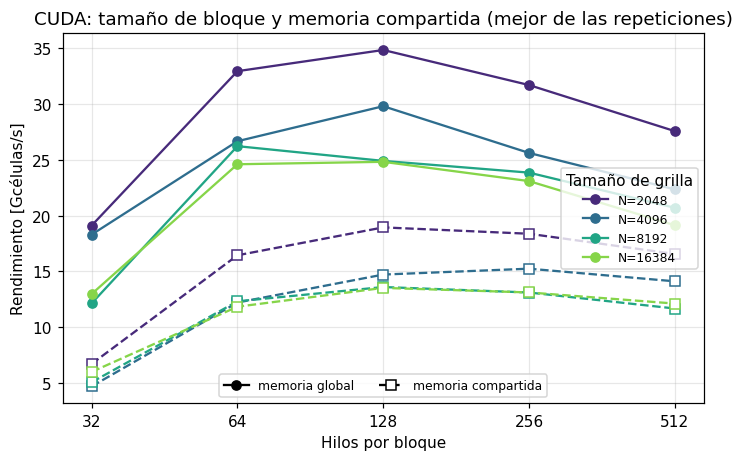

In [2]:
ob = best(opt, ['rows', 'block', 'shared'])
ob['G'] = ob.mcells_kernel / 1000.0          # Gcélulas/s

fig, ax = plt.subplots(figsize=(6.6, 4.3))
Ns = [2048, 4096, 8192, 16384]
colors = plt.cm.viridis(np.linspace(0.12, 0.82, len(Ns)))
for n, c in zip(Ns, colors):
    g = ob[(ob.rows == n) & (ob.shared == 0)].sort_values('block')
    s = ob[(ob.rows == n) & (ob.shared == 1)].sort_values('block')
    ax.plot(g.block, g.G, '-o', color=c, label=f'N={n}')
    ax.plot(s.block, s.G, '--s', color=c, mfc='white')

ax.set_xscale('log', base=2)
ax.set_xticks([32, 64, 128, 256, 512]); ax.set_xticklabels([32, 64, 128, 256, 512])
ax.set_xlabel('Hilos por bloque'); ax.set_ylabel('Rendimiento [Gcélulas/s]')
ax.set_title('CUDA: tamaño de bloque y memoria compartida (mejor de las repeticiones)')
leg1 = ax.legend(title='Tamaño de grilla', fontsize=8, loc='center right')
ax.add_artist(leg1)
style = [Line2D([], [], color='k', ls='-', marker='o', label='memoria global'),
         Line2D([], [], color='k', ls='--', marker='s', mfc='white', label='memoria compartida')]
ax.legend(handles=style, fontsize=8, loc='lower center', ncol=2)
fig.tight_layout(); fig.savefig(IMG / 'bench_block_shared.png', dpi=150, bbox_inches='tight')

# Resumen numérico (global vs compartida, mejor bloque por N)
gbest = ob[ob.shared==0].loc[ob[ob.shared==0].groupby('rows').G.idxmax()]
sbest = ob[ob.shared==1].loc[ob[ob.shared==1].groupby('rows').G.idxmax()]
tab = gbest.merge(sbest, on='rows', suffixes=('_glob','_shar'))
tab['global/compartida'] = (tab.G_glob / tab.G_shar).round(2)
print(tab[['rows','block_glob','G_glob','block_shar','G_shar','global/compartida']]
      .rename(columns={'block_glob':'mejor_blk_glob','G_glob':'Gcel_glob',
                       'block_shar':'mejor_blk_shar','G_shar':'Gcel_shar'})
      .to_string(index=False))

## 2. CPU: escalamiento por número de hilos

El reparto por bandas de filas escala **casi linealmente hasta los 6 núcleos
físicos** (~5,4× con 6 hilos). El *hyperthreading* aporta poco (12 hilos ≈ 5,9×):
el problema está limitado por cómputo, no por los núcleos lógicos.

El detalle más llamativo es la **caída no monótona en 8 y 10 hilos**: 8 hilos
rinde *menos* que 6. Con 8 hilos, 2 de los 6 núcleos físicos ejecutan 2 hilos HT
(cada uno ~0,65× de velocidad) y 4 ejecutan 1 hilo; como la `std::barrier`
sincroniza cada generación, **el paso espera al hilo más lento**, y los núcleos
con HT se vuelven el cuello de botella. Con 12 hilos todos los núcleos están
igualmente cargados (2 HT cada uno), el reparto vuelve a ser balanceado y el
rendimiento se recupera. (No es térmico: el calentamiento haría caer también a
10 y 12 hilos, y ahí se recupera.)

threads    1     2      4      6      8      10     12
rows                                                  
64       29.2  56.8  100.1  122.5   92.3  104.9  115.0
128      29.3  57.1  106.3  144.8   99.0  121.9  148.0
256      29.1  55.5  106.6  151.1   99.4  125.1  159.9
512      28.3  54.1  105.0  149.8  106.2  132.0  157.2
1024     27.7  53.3  103.1  148.4  110.3  135.1  159.7
2048     27.0  51.9  101.0  145.1  112.4  135.4  159.1
4096     26.5  51.3   98.6  143.0  116.3  134.9  148.7
8192     26.0  50.2   96.2  140.8  126.2  137.6  154.0
16384     NaN  49.7   95.0  139.9  130.7  142.8  158.5

speed-up paralelo vs 1 hilo (N=4096):  t1=1.0x, t2=1.9x, t4=3.7x, t6=5.4x, t8=4.4x, t10=5.1x, t12=5.6x


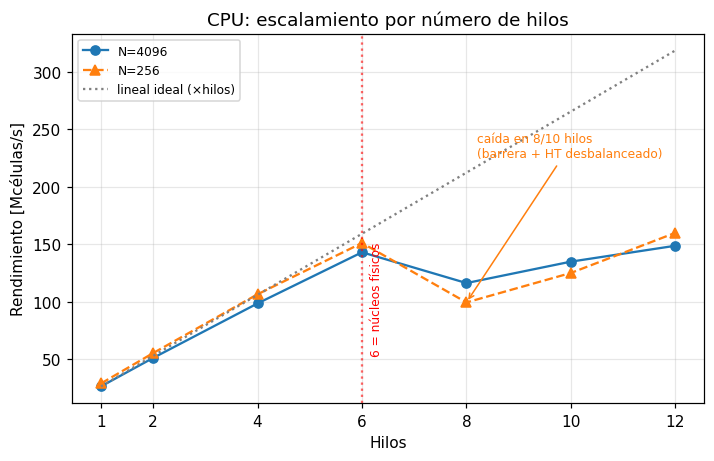

In [3]:
cb = best(cpu, ['rows', 'threads'])
fig, ax = plt.subplots(figsize=(6.6, 4.3))
for n, sty in [(4096, '-o'), (256, '--^')]:
    d = cb[cb.rows == n].sort_values('threads')
    ax.plot(d.threads, d.mcells_kernel, sty, label=f'N={n}')

d4 = cb[cb.rows == 4096].sort_values('threads')
base = float(d4[d4.threads == 1].mcells_kernel.iloc[0])
ax.plot(d4.threads, base * d4.threads, ':', color='grey', label='lineal ideal (×hilos)')
ax.axvline(6, color='red', ls=':', alpha=0.6)
ax.text(6.15, base * 2.0, '6 = núcleos físicos', color='red', fontsize=8, rotation=90, va='bottom')
ax.annotate('caída en 8/10 hilos\n(barrera + HT desbalanceado)',
            xy=(8, float(cb[(cb.rows==256)&(cb.threads==8)].mcells_kernel.iloc[0])),
            xytext=(8.2, base * 8.5), fontsize=8, color='C1',
            arrowprops=dict(arrowstyle='->', color='C1'))
ax.set_xticks([1, 2, 4, 6, 8, 10, 12])
ax.set_xlabel('Hilos'); ax.set_ylabel('Rendimiento [Mcélulas/s]')
ax.set_title('CPU: escalamiento por número de hilos')
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(IMG / 'bench_cpu_threads.png', dpi=150, bbox_inches='tight')

piv = cb.pivot(index='rows', columns='threads', values='mcells_kernel').round(1)
print(piv.to_string())
print('\nspeed-up paralelo vs 1 hilo (N=4096): ',
      ', '.join(f't{int(t)}={piv.loc[4096, t] / piv.loc[4096, 1]:.1f}x' for t in piv.columns))

## 3. CPU vs GPU según el tamaño de grilla

En ejes log–log: la CPU secuencial es **plana** (~27 Mcélulas/s, limitada por
cómputo), la paralela se estabiliza en ~150–160, y la GPU domina por **dos a tres
órdenes de magnitud**, con su máximo (~32 Gcélulas/s) en N=2048. A partir de ahí
el rendimiento de la GPU decae un poco (la grilla excede la caché L2 y la
reutilización baja).

La línea punteada `CUDA (wall)` incluye el costo de lanzamiento por paso: para
grillas pequeñas se separa del `kernel` (la GPU está infrautilizada), pero
**aun así supera a la CPU en todo el rango medido** —porque la métrica excluye las
transferencias *host*↔*device*.

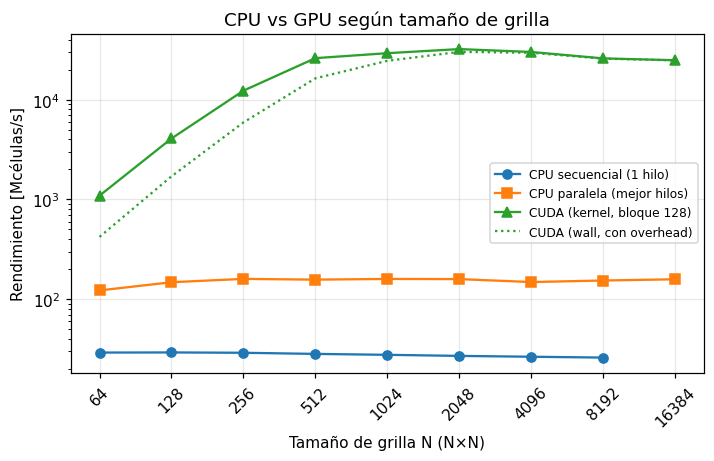

In [4]:
cuda_b = best(cuda, ['rows'])
cuda_w = best(cuda, ['rows'], 'mcells_wall')
seq_b  = best(cpu[cpu.threads == 1], ['rows'])
par_b  = best(cpu, ['rows'])           # mejor sobre todos los hilos

fig, ax = plt.subplots(figsize=(6.6, 4.3))
ax.plot(seq_b.rows,  seq_b.mcells_kernel,  '-o', label='CPU secuencial (1 hilo)')
ax.plot(par_b.rows,  par_b.mcells_kernel,  '-s', label='CPU paralela (mejor hilos)')
ax.plot(cuda_b.rows, cuda_b.mcells_kernel, '-^', color='C2', label='CUDA (kernel, bloque 128)')
ax.plot(cuda_w.rows, cuda_w.mcells_wall,   ':',  color='C2', label='CUDA (wall, con overhead)')
ax.set_xscale('log', base=2); ax.set_yscale('log')
xs = sorted(cuda_b.rows.unique())
ax.set_xticks(xs); ax.set_xticklabels(xs, rotation=45)
ax.set_xlabel('Tamaño de grilla N (N×N)'); ax.set_ylabel('Rendimiento [Mcélulas/s]')
ax.set_title('CPU vs GPU según tamaño de grilla')
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(IMG / 'bench_cpu_vs_gpu.png', dpi=150, bbox_inches='tight')

## 4. Speed-up y umbral de conveniencia

*Izquierda:* el *speed-up* de la GPU alcanza **~1200× frente a la versión
secuencial** y **~200× frente a la mejor CPU paralela**, con su máximo en
N=2048–4096. *Derecha:* la eficiencia `wall/kernel` mide el peso del overhead de
lanzamiento; sube de ~40 % en N=64 a ~98 % en N≥2048, por lo que la **rodilla**
de conveniencia está en **N≈1024–2048**. Como la métrica no incluye transferencias,
no aparece un umbral por debajo del cual convenga la CPU: este aparecería al
contabilizar el costo PCIe de subir/bajar la grilla.

 rows  cpu_seq  cpu_par  cuda_k  cuda_w  S_seq  S_par  eff
   64     29.0    123.0  1092.0   422.0   37.0    9.0 38.6
  128     29.0    148.0  4081.0  1704.0  139.0   28.0 41.8
  256     29.0    160.0 12301.0  5914.0  423.0   77.0 48.1
  512     28.0    157.0 26068.0 16364.0  920.0  166.0 62.8
 1024     28.0    160.0 29227.0 24502.0 1054.0  183.0 83.8
 2048     27.0    159.0 32120.0 30141.0 1188.0  202.0 93.8
 4096     27.0    149.0 30057.0 29499.0 1133.0  202.0 98.1
 8192     26.0    154.0 25915.0 25766.0  996.0  168.0 99.4
16384      NaN    158.0 24834.0 24773.0    NaN  157.0 99.8


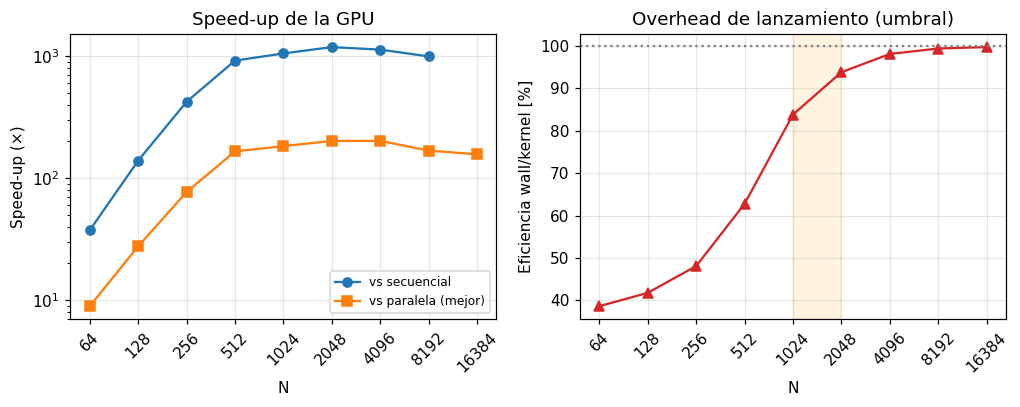

In [5]:
m = cuda_b.rename(columns={'mcells_kernel': 'cuda_k'}).merge(
        cuda_w.rename(columns={'mcells_wall': 'cuda_w'}), on='rows').merge(
        par_b.rename(columns={'mcells_kernel': 'cpu_par'}), on='rows').merge(
        seq_b.rename(columns={'mcells_kernel': 'cpu_seq'}), on='rows', how='left')
m['S_seq'] = m.cuda_k / m.cpu_seq
m['S_par'] = m.cuda_k / m.cpu_par
m['eff']   = 100 * m.cuda_w / m.cuda_k

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.8))
a1.plot(m.rows, m.S_seq, '-o', label='vs secuencial')
a1.plot(m.rows, m.S_par, '-s', label='vs paralela (mejor)')
a1.set_xscale('log', base=2); a1.set_yscale('log')
a1.set_xlabel('N'); a1.set_ylabel('Speed-up (×)'); a1.set_title('Speed-up de la GPU')
a1.legend(fontsize=8)

a2.plot(m.rows, m.eff, '-^', color='C3')
a2.axhline(100, ls=':', color='grey')
a2.axvspan(1024, 2048, color='orange', alpha=0.12)
a2.set_xscale('log', base=2)
a2.set_xlabel('N'); a2.set_ylabel('Eficiencia wall/kernel [%]')
a2.set_title('Overhead de lanzamiento (umbral)')
for a in (a1, a2):
    a.set_xticks(m.rows); a.set_xticklabels(m.rows, rotation=45)
fig.tight_layout(); fig.savefig(IMG / 'bench_speedup.png', dpi=150, bbox_inches='tight')

print(m[['rows','cpu_seq','cpu_par','cuda_k','cuda_w','S_seq','S_par','eff']]
      .round({'cpu_seq':0,'cpu_par':0,'cuda_k':0,'cuda_w':0,'S_seq':0,'S_par':0,'eff':1})
      .to_string(index=False))

## Resumen

- **Memoria compartida:** contraproducente para este *stencil* de 1 byte
  (~0,55× del rendimiento global). Confirma la predicción del modelo *roofline*.
- **Tamaño de bloque:** óptimo en 64–128 hilos; curva cóncava por ocupación.
- **CPU:** escala hasta 6 núcleos físicos; HT aporta poco y desbalancea la barrera
  en 8/10 hilos.
- **GPU:** ~32 Gcélulas/s máx., limitada por el ancho de banda de GDDR6.
- **Speed-up:** hasta ~200× sobre la mejor CPU paralela; la GPU conviene desde
  grillas pequeñas (excluyendo transferencias), con la rodilla de eficiencia en
  N≈1024–2048.